## Comparison of NNLS and L2reg

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.globals as gl
import matplotlib.pyplot as plt
from scipy import stats

#### Loading Evaluation of NNLS and L2reg Global Models

In [2]:
methods = ['NNLS', 'L2reg']
train_ds_list = gl.get_ldo_names()
eval_ds_list = gl.datasets
eval_ds_names = [ds if gl.sessions[i] == 'all' else ds + gl.sessions[i].split('-')[1] for i, ds in enumerate(gl.datasets)]
df_all = pd.DataFrame()
for i, (ds_code, ds_eval) in enumerate(zip(train_ds_list, eval_ds_names)):
    df = rm.comb_eval(models=[ds_code+"-global-Cavg"],methods=methods,eval_data=[ds_eval],cerebellum='MNISymC3')
    df_all = pd.concat([df_all, df], ignore_index=True)
df_all['logalpha'] = df_all['logalpha'].fillna(-2)

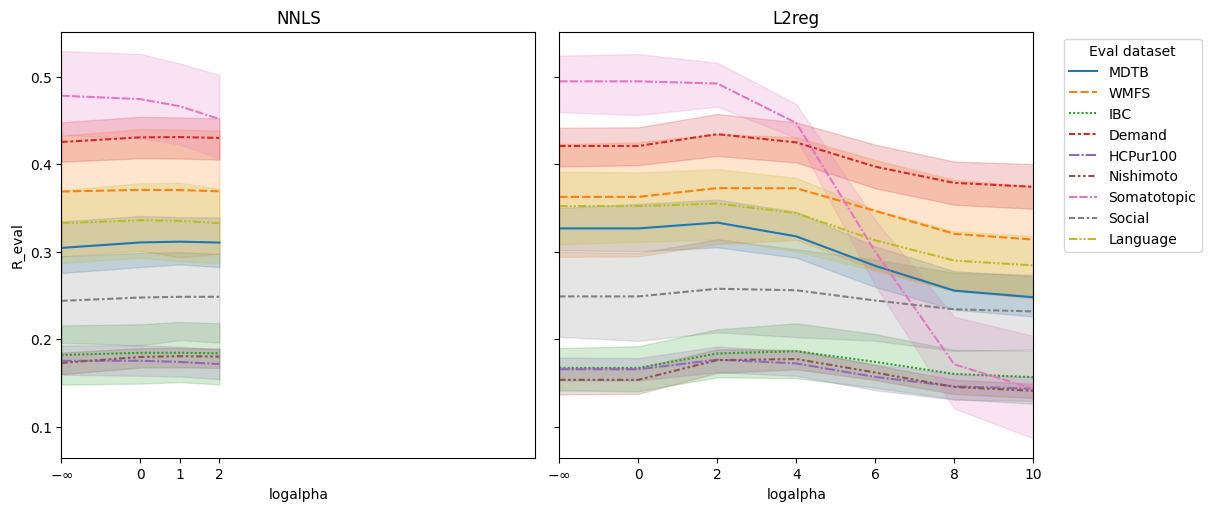

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey='row', constrained_layout=True)
for i, method in enumerate(methods):
    sns.lineplot(data=df_all[df_all['method']==method], y='R_eval', x='logalpha',
                hue='eval_dataset', style='eval_dataset',
                hue_order=eval_ds_list, style_order=eval_ds_list, ax=axes[i])
    axes[i].set_title(method)
    if i == 0:
        axes[i].legend_.remove()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Eval dataset');

for i in range(2):
    xticks = df_all[df_all['method']==methods[i]]['logalpha'].unique()
    xticklabels = [r"$-\infty$" if np.isclose(t, -2) else str(int(t)) for t in xticks]
    axes[i].set_xticks(xticks)
    axes[i].set_xticklabels(xticklabels)
axes[0].set_xlim([-2, 10]);
axes[1].set_xlim([-2, 10]);

#### Finding best log alpha

In [4]:
for method in methods:
    print(f'\nMethod: {method}')
    df_method = df_all[df_all['method'] == method]
    A = pd.pivot_table(df_method, index=['train_dataset'], columns=['logalpha'], values=['R_eval'], aggfunc='mean').reindex(train_ds_list)
    display(A)
    B = np.nan_to_num(A.values)
    ind = B.argmax(axis=1)
    log_a = np.array(A.columns.get_level_values(1)[ind])
    bestla = pd.DataFrame(log_a, index=A.index, columns=['best_logalpha'])
    display(bestla)
    df_all.loc[df_method.index, 'isbest'] = df_method['logalpha'].values == bestla.loc[df_method['train_dataset']].values.flatten()
df_best = df_all[df_all['isbest']]


Method: NNLS


R_eval                              
logalpha              -2.0       0.0       1.0       2.0
train_dataset                                           
WfIbDeHtNiSoScLa  0.304258  0.310483  0.311365  0.310375
MdIbDeHtNiSoScLa  0.368716  0.370499  0.370368  0.368962
MdWfDeHtNiSoScLa  0.181903  0.184372  0.184409  0.183878
MdWfIbHtNiSoScLa  0.425267  0.430557  0.430895  0.429844
MdWfIbDeNiSoScLa  0.175261  0.175300  0.173965  0.171527
MdWfIbDeHtSoScLa  0.172810  0.179653  0.180536  0.180045
MdWfIbDeHtNiScLa  0.478150  0.474231  0.466116  0.451514
MdWfIbDeHtNiSoLa  0.243729  0.247546  0.248378  0.248401
MdWfIbDeHtNiSoSc  0.332486  0.335887  0.335201  0.332501

,best_logalpha
train_dataset,
WfIbDeHtNiSoScLa,1.0
MdIbDeHtNiSoScLa,0.0
MdWfDeHtNiSoScLa,1.0
MdWfIbHtNiSoScLa,1.0
MdWfIbDeNiSoScLa,0.0
MdWfIbDeHtSoScLa,1.0
MdWfIbDeHtNiScLa,-2.0
MdWfIbDeHtNiSoLa,2.0
MdWfIbDeHtNiSoSc,0.0



Method: L2reg


R_eval                                                    \
logalpha             -2.0       0.0       2.0       4.0       6.0       8.0    
train_dataset                                                                  
WfIbDeHtNiSoScLa  0.326523  0.326523  0.333173  0.317415  0.283730  0.255443   
MdIbDeHtNiSoScLa  0.362533  0.362533  0.372571  0.372397  0.346537  0.320317   
MdWfDeHtNiSoScLa  0.167159  0.167159  0.183634  0.186199  0.173978  0.160248   
MdWfIbHtNiSoScLa  0.420686  0.420686  0.434203  0.424794  0.397047  0.378550   
MdWfIbDeNiSoScLa  0.165545  0.165545  0.176506  0.172291  0.156758  0.146009   
MdWfIbDeHtSoScLa  0.153482  0.153482  0.176013  0.177293  0.161848  0.145336   
MdWfIbDeHtNiScLa  0.494568  0.494568  0.492067  0.446991  0.299810  0.171113   
MdWfIbDeHtNiSoLa  0.248809  0.248809  0.257564  0.255849  0.244144  0.234106   
MdWfIbDeHtNiSoSc  0.352021  0.352021  0.354918  0.343936  0.312926  0.289758   

                            
logalpha              10.0  
train_dataset               
WfIbDeHtNiSoScLa  0.247895  
MdIbDeHtNiSoScLa  0.313773  
MdWfDeHtNiSoScLa  0.156540  
MdWfIbHtNiSoScLa  0.374066  
MdWfIbDeNiSoScLa  0.143377  
MdWfIbDeHtSoScLa  0.140918  
MdWfIbDeHtNiScLa  0.143481  
MdWfIbDeHtNiSoLa  0.231666  
MdWfIbDeHtNiSoSc  0.284262

,best_logalpha
train_dataset,
WfIbDeHtNiSoScLa,2.0
MdIbDeHtNiSoScLa,2.0
MdWfDeHtNiSoScLa,4.0
MdWfIbHtNiSoScLa,2.0
MdWfIbDeNiSoScLa,2.0
MdWfIbDeHtSoScLa,4.0
MdWfIbDeHtNiScLa,-2.0
MdWfIbDeHtNiSoLa,2.0
MdWfIbDeHtNiSoSc,2.0


#### Statistical Test for Method Comparison

In [8]:
alpha = 0.05
for i, (dataset, group) in enumerate(df_best.groupby("train_dataset")):
    # Reshape into subject × method table
    pivot = group.pivot(index="eval_subj", columns="method", values="R_eval")
    pivot = pivot.dropna()

    # Paired t-test (two-sided)
    stat, p = stats.ttest_rel(pivot[methods[0]], pivot[methods[1]], alternative="two-sided")
    dof = pivot.shape[0] - 1

    # Report results
    mean_A = pivot[methods[0]].mean()
    mean_B = pivot[methods[1]].mean()
    mean_diff = (pivot[methods[0]] - pivot[methods[1]]).mean()

    if p < alpha:
        if mean_diff > 0:
            conclusion = f"{methods[0]} is significantly greater than {methods[1]}"
        else:
            conclusion = f"{methods[1]} is significantly greater than {methods[0]}"
    else:
        conclusion = "No significant difference"

    print(f"Dataset: {dataset} (eval on {eval_ds_list[train_ds_list.index(dataset)]})")
    print(f"  mean({methods[0]}) = {mean_A:.3f}, mean({methods[1]}) = {mean_B:.3f}")
    print(f"  dof = {dof}, t-stat = {stat:.3f}, p = {p:.3g} → {conclusion}\n")

Dataset: MdIbDeHtNiSoScLa (eval on WMFS)
  mean(NNLS) = 0.370, mean(L2reg) = 0.373
  dof = 15, t-stat = -0.247, p = 0.808 → No significant difference

Dataset: MdWfDeHtNiSoScLa (eval on IBC)
  mean(NNLS) = 0.184, mean(L2reg) = 0.186
  dof = 11, t-stat = -0.390, p = 0.704 → No significant difference

Dataset: MdWfIbDeHtNiScLa (eval on Somatotopic)
  mean(NNLS) = 0.478, mean(L2reg) = 0.495
  dof = 7, t-stat = -0.810, p = 0.445 → No significant difference

Dataset: MdWfIbDeHtNiSoLa (eval on Social)
  mean(NNLS) = 0.248, mean(L2reg) = 0.258
  dof = 21, t-stat = -2.048, p = 0.0532 → No significant difference

Dataset: MdWfIbDeHtNiSoSc (eval on Language)
  mean(NNLS) = 0.336, mean(L2reg) = 0.355
  dof = 16, t-stat = -2.830, p = 0.0121 → L2reg is significantly greater than NNLS

Dataset: MdWfIbDeHtSoScLa (eval on Nishimoto)
  mean(NNLS) = 0.181, mean(L2reg) = 0.177
  dof = 5, t-stat = 0.438, p = 0.68 → No significant difference

Dataset: MdWfIbDeNiSoScLa (eval on HCPur100)
  mean(NNLS) = 0.17

#### Overall test

In [20]:
pivot = df_best.pivot(index=["train_dataset", "eval_subj"], 
                      columns="method", values="R_eval")
pivot = pivot.dropna()
diff = pivot[methods[0]] - pivot[methods[1]]

# test across all datasets/subjects
stat, p = stats.ttest_rel(pivot[methods[0]], pivot[methods[1]], alternative="two-sided")
dof = pivot.shape[0] - 1

mean_diff = diff.mean()
if p < alpha:
    if mean_diff > 0:
        conclusion = f"{methods[0]} is significantly greater than {methods[1]}"
    else:
        conclusion = f"{methods[1]} is significantly greater than {methods[0]}"
else:
    conclusion = "No significant difference"

print("Across-subject test:")
print(f"  dof = {dof}, t = {stat:.3f}, p = {p:.2e}")
print(f"  mean({methods[0]} - {methods[1]}) = {mean_diff:.3f} → {conclusion}") 

Across-subject test:
  dof = 191, t = -3.386, p = 8.61e-04
  mean(NNLS - L2reg) = -0.007 → L2reg is significantly greater than NNLS


In [21]:
# mean R_eval per train_dataset
mean_by_dataset = pivot.groupby(level=0).mean().reindex(train_ds_list)

# paired t-test across datasets (each dataset contributes one mean)
stat_ds, p_ds = stats.ttest_rel(mean_by_dataset[methods[0]], mean_by_dataset[methods[1]], alternative="two-sided")
dof_ds = mean_by_dataset.shape[0] - 1
mean_diff_ds = (mean_by_dataset[methods[0]] - mean_by_dataset[methods[1]]).mean()

if p_ds < alpha:
    if mean_diff_ds > 0:
        conclusion_ds = f"{methods[0]} is significantly greater than {methods[1]}"
    else:
        conclusion_ds = f"{methods[1]} is significantly greater than {methods[0]}"
else:
    conclusion_ds = "No significant difference"

print("Across-dataset test:")
print(f"  dof = {dof_ds}, t = {stat_ds:.3f}, p = {p_ds:.2e}")
print(f"  mean({methods[0]} - {methods[1]}) = {mean_diff_ds:.3f} → {conclusion_ds}")

Across-dataset test:
  dof = 8, t = -2.640, p = 2.97e-02
  mean(NNLS - L2reg) = -0.008 → L2reg is significantly greater than NNLS
